# Global Tourism Travel Trends — Full EDA Workflow
### Author: Justice Tefera
### Purpose: Clean, analyze, and visualize global tourism microdata
### Repository: https://github.com/justicetefera/datafun-06-applied
### Date: 2026-06


About This Notebook
This notebook follows a structured EDA workflow inspired by Dr. Case’s Applied Analytics template.
It includes:

Cleaning the raw dataset

Exporting a GitHub‑ready clean CSV

Exploring structure, quality, and patterns

Visualizing key tourism behaviors

In [21]:
import os

if "notebooks" in os.getcwd().replace("\\", "/"):
    os.chdir("..")

os.getcwd()

'c:\\Users\\JTEFE\\Repos\\datafun-06-applied'

In [22]:
from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

LOG = get_logger("Tourism-NB", level="DEBUG")
log_header(LOG, "Tourism-NB")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-06-17 15:04:32 | INFO | Tourism-NB | === RUN START ===
2026-06-17 15:04:32 | INFO | Tourism-NB | project=Tourism-NB
2026-06-17 15:04:32 | INFO | Tourism-NB | repo_dir=datafun-06-applied
2026-06-17 15:04:32 | INFO | Tourism-NB | python=3.14.5
2026-06-17 15:04:32 | INFO | Tourism-NB | os=Windows 11
2026-06-17 15:04:32 | INFO | Tourism-NB | shell=powershell
2026-06-17 15:04:32 | INFO | Tourism-NB | cwd=.
2026-06-17 15:04:32 | INFO | Tourism-NB | github_actions=False


In [23]:
raw_path = "data/raw/global_tourism_travel_trends.csv"
df = pd.read_csv(raw_path)

LOG.info("Raw dataset loaded.")
df.head()

2026-06-17 15:04:32 | INFO | Tourism-NB | Raw dataset loaded.


,trip_id,year,month,season,origin_country,destination_country,travel_purpose,traveler_type,num_travelers,duration_nights,transport_mode,accommodation_type,visa_type,booking_channel,advance_booking_days,budget_per_person_usd,total_trip_spend_usd,restaurant_spend_per_day_usd,attractions_visited,local_transport_used,travel_insurance,repeat_visitor,overall_satisfaction,trip_rating,safety_perception,language_barrier,wifi_satisfaction,would_recommend,social_media_shared,eco_friendly_choices,carbon_footprint_kg_co2,currency_satisfaction,health_safety_compliance
0,TRP0000001,2022,4,Autumn (Sep-Nov),China,USA,Business,Couple,2,6,Air,5-Star Hotel,Visa on Arrival,Travel Agent,63,2821.80,5643.60,24.46,2,Taxi/Ride-share,No,Yes,Dissatisfied,4,Safe,Moderate,Good,Maybe,Instagram,No,1234.3,Unfavorable,NaN
1,TRP0000002,2024,7,Spring (Mar-May),South Korea,Spain,Leisure/Tourism,Family,4,6,Rail,3-Star Hotel,Visa-Free,Travel Agent,19,4750.42,19001.68,29.46,7,Public Transport,No,Yes,Very Satisfied,4,Unsafe,Mild,Good,Maybe,Facebook,No,141.8,Very Unfavorable,NaN
2,TRP0000003,2022,9,Winter (Dec-Feb),Pakistan,USA,Leisure/Tourism,Group Tour,24,14,Air,3-Star Hotel,Visa on Arrival,Travel Agent,29,1823.49,43763.76,52.54,6,Rental Car,Yes,No,Neutral,5,Neutral,Moderate,Average,Maybe,Facebook,Yes,20410.1,Neutral,Full
3,TRP0000004,2019,7,Summer (Jun-Aug),Italy,Egypt,Leisure/Tourism,Solo,1,17,Air,4-Star Hotel,Embassy Visa,Direct Hotel/Airline,20,4474.59,4474.59,45.78,4,Taxi/Ride-share,No,Yes,Dissatisfied,2,Neutral,Moderate,Excellent,Definitely,Instagram,No,624.7,Unfavorable,Full
4,TRP0000005,2024,12,Spring (Mar-May),USA,New Zealand,Adventure/Sports,Solo,1,16,Cruise Ship,4-Star Hotel,Visa-Free,Mobile App,22,2546.87,2546.87,178.04,6,Taxi/Ride-share,No,Yes,Satisfied,5,Very Safe,Moderate,Good,Maybe,Instagram,Yes,263.4,Neutral,Full


In [24]:
LOG.info("Dataset shape and columns:")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

df.head()

2026-06-17 15:04:33 | INFO | Tourism-NB | Dataset shape and columns:


Shape: (10000, 33)
Columns: ['trip_id', 'year', 'month', 'season', 'origin_country', 'destination_country', 'travel_purpose', 'traveler_type', 'num_travelers', 'duration_nights', 'transport_mode', 'accommodation_type', 'visa_type', 'booking_channel', 'advance_booking_days', 'budget_per_person_usd', 'total_trip_spend_usd', 'restaurant_spend_per_day_usd', 'attractions_visited', 'local_transport_used', 'travel_insurance', 'repeat_visitor', 'overall_satisfaction', 'trip_rating', 'safety_perception', 'language_barrier', 'wifi_satisfaction', 'would_recommend', 'social_media_shared', 'eco_friendly_choices', 'carbon_footprint_kg_co2', 'currency_satisfaction', 'health_safety_compliance']


,trip_id,year,month,season,origin_country,destination_country,travel_purpose,traveler_type,num_travelers,duration_nights,transport_mode,accommodation_type,visa_type,booking_channel,advance_booking_days,budget_per_person_usd,total_trip_spend_usd,restaurant_spend_per_day_usd,attractions_visited,local_transport_used,travel_insurance,repeat_visitor,overall_satisfaction,trip_rating,safety_perception,language_barrier,wifi_satisfaction,would_recommend,social_media_shared,eco_friendly_choices,carbon_footprint_kg_co2,currency_satisfaction,health_safety_compliance
0,TRP0000001,2022,4,Autumn (Sep-Nov),China,USA,Business,Couple,2,6,Air,5-Star Hotel,Visa on Arrival,Travel Agent,63,2821.80,5643.60,24.46,2,Taxi/Ride-share,No,Yes,Dissatisfied,4,Safe,Moderate,Good,Maybe,Instagram,No,1234.3,Unfavorable,NaN
1,TRP0000002,2024,7,Spring (Mar-May),South Korea,Spain,Leisure/Tourism,Family,4,6,Rail,3-Star Hotel,Visa-Free,Travel Agent,19,4750.42,19001.68,29.46,7,Public Transport,No,Yes,Very Satisfied,4,Unsafe,Mild,Good,Maybe,Facebook,No,141.8,Very Unfavorable,NaN
2,TRP0000003,2022,9,Winter (Dec-Feb),Pakistan,USA,Leisure/Tourism,Group Tour,24,14,Air,3-Star Hotel,Visa on Arrival,Travel Agent,29,1823.49,43763.76,52.54,6,Rental Car,Yes,No,Neutral,5,Neutral,Moderate,Average,Maybe,Facebook,Yes,20410.1,Neutral,Full
3,TRP0000004,2019,7,Summer (Jun-Aug),Italy,Egypt,Leisure/Tourism,Solo,1,17,Air,4-Star Hotel,Embassy Visa,Direct Hotel/Airline,20,4474.59,4474.59,45.78,4,Taxi/Ride-share,No,Yes,Dissatisfied,2,Neutral,Moderate,Excellent,Definitely,Instagram,No,624.7,Unfavorable,Full
4,TRP0000005,2024,12,Spring (Mar-May),USA,New Zealand,Adventure/Sports,Solo,1,16,Cruise Ship,4-Star Hotel,Visa-Free,Mobile App,22,2546.87,2546.87,178.04,6,Taxi/Ride-share,No,Yes,Satisfied,5,Very Safe,Moderate,Good,Maybe,Instagram,Yes,263.4,Neutral,Full


In [25]:
df_clean = df.copy()

df_clean.columns = (
    df_clean.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
)

LOG.info("Column names standardized.")
list(df_clean.columns)

2026-06-17 15:04:33 | INFO | Tourism-NB | Column names standardized.


['trip_id',
 'year',
 'month',
 'season',
 'origin_country',
 'destination_country',
 'travel_purpose',
 'traveler_type',
 'num_travelers',
 'duration_nights',
 'transport_mode',
 'accommodation_type',
 'visa_type',
 'booking_channel',
 'advance_booking_days',
 'budget_per_person_usd',
 'total_trip_spend_usd',
 'restaurant_spend_per_day_usd',
 'attractions_visited',
 'local_transport_used',
 'travel_insurance',
 'repeat_visitor',
 'overall_satisfaction',
 'trip_rating',
 'safety_perception',
 'language_barrier',
 'wifi_satisfaction',
 'would_recommend',
 'social_media_shared',
 'eco_friendly_choices',
 'carbon_footprint_kg_co2',
 'currency_satisfaction',
 'health_safety_compliance']

In [26]:
required_cols = [
    "trip_id",
    "year",
    "origin_country",
    "destination_country",
    "num_travelers",
    "total_trip_spend_usd",
]

numeric_cols = [
    "year",
    "num_travelers",
    "duration_nights",
    "budget_per_person_usd",
    "total_trip_spend_usd",
    "restaurant_spend_per_day_usd",
    "carbon_footprint_kg_co2",
    "trip_rating",
]

df_clean = df_clean.dropna(subset=required_cols)

for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean = df_clean.dropna(subset=["year", "num_travelers", "total_trip_spend_usd"])

LOG.info("Missing values handled.")
df_clean.head()

2026-06-17 15:04:33 | INFO | Tourism-NB | Missing values handled.


,trip_id,year,month,season,origin_country,destination_country,travel_purpose,traveler_type,num_travelers,duration_nights,transport_mode,accommodation_type,visa_type,booking_channel,advance_booking_days,budget_per_person_usd,total_trip_spend_usd,restaurant_spend_per_day_usd,attractions_visited,local_transport_used,travel_insurance,repeat_visitor,overall_satisfaction,trip_rating,safety_perception,language_barrier,wifi_satisfaction,would_recommend,social_media_shared,eco_friendly_choices,carbon_footprint_kg_co2,currency_satisfaction,health_safety_compliance
0,TRP0000001,2022,4,Autumn (Sep-Nov),China,USA,Business,Couple,2,6,Air,5-Star Hotel,Visa on Arrival,Travel Agent,63,2821.80,5643.60,24.46,2,Taxi/Ride-share,No,Yes,Dissatisfied,4,Safe,Moderate,Good,Maybe,Instagram,No,1234.3,Unfavorable,NaN
1,TRP0000002,2024,7,Spring (Mar-May),South Korea,Spain,Leisure/Tourism,Family,4,6,Rail,3-Star Hotel,Visa-Free,Travel Agent,19,4750.42,19001.68,29.46,7,Public Transport,No,Yes,Very Satisfied,4,Unsafe,Mild,Good,Maybe,Facebook,No,141.8,Very Unfavorable,NaN
2,TRP0000003,2022,9,Winter (Dec-Feb),Pakistan,USA,Leisure/Tourism,Group Tour,24,14,Air,3-Star Hotel,Visa on Arrival,Travel Agent,29,1823.49,43763.76,52.54,6,Rental Car,Yes,No,Neutral,5,Neutral,Moderate,Average,Maybe,Facebook,Yes,20410.1,Neutral,Full
3,TRP0000004,2019,7,Summer (Jun-Aug),Italy,Egypt,Leisure/Tourism,Solo,1,17,Air,4-Star Hotel,Embassy Visa,Direct Hotel/Airline,20,4474.59,4474.59,45.78,4,Taxi/Ride-share,No,Yes,Dissatisfied,2,Neutral,Moderate,Excellent,Definitely,Instagram,No,624.7,Unfavorable,Full
4,TRP0000005,2024,12,Spring (Mar-May),USA,New Zealand,Adventure/Sports,Solo,1,16,Cruise Ship,4-Star Hotel,Visa-Free,Mobile App,22,2546.87,2546.87,178.04,6,Taxi/Ride-share,No,Yes,Satisfied,5,Very Safe,Moderate,Good,Maybe,Instagram,Yes,263.4,Neutral,Full


In [27]:
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after = df_clean.shape[0]

LOG.info(f"Removed {before - after} duplicate rows.")
df_clean.shape

2026-06-17 15:04:33 | INFO | Tourism-NB | Removed 0 duplicate rows.


(10000, 33)

In [28]:
output_path = "data/clean/global_tourism_travel_trends_clean.csv"
df_clean.to_csv(output_path, index=False)

LOG.info(f"Clean dataset saved to: {output_path}")
print(f"Clean dataset saved to: {output_path}")

2026-06-17 15:04:33 | INFO | Tourism-NB | Clean dataset saved to: data/clean/global_tourism_travel_trends_clean.csv


Clean dataset saved to: data/clean/global_tourism_travel_trends_clean.csv


In [29]:
df_clean.head()
df_clean.info()
df_clean.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   trip_id                       10000 non-null  str    
 1   year                          10000 non-null  int64  
 2   month                         10000 non-null  int64  
 3   season                        10000 non-null  str    
 4   origin_country                10000 non-null  str    
 5   destination_country           10000 non-null  str    
 6   travel_purpose                10000 non-null  str    
 7   traveler_type                 10000 non-null  str    
 8   num_travelers                 10000 non-null  int64  
 9   duration_nights               10000 non-null  int64  
 10  transport_mode                10000 non-null  str    
 11  accommodation_type            10000 non-null  str    
 12  visa_type                     10000 non-null  str    
 13  booking_chann

,year,month,num_travelers,duration_nights,advance_booking_days,budget_per_person_usd,total_trip_spend_usd,restaurant_spend_per_day_usd,attractions_visited,trip_rating,carbon_footprint_kg_co2
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,2022.033100,6.501500,4.594000,17.469900,44.376700,2558.939043,11549.689369,78.709287,4.501200,3.9444,1671.853180
std,1.726934,3.471744,6.431819,25.891688,40.883749,2694.140147,25903.116427,51.109475,2.113539,1.0030,3197.487926
min,2019.000000,1.000000,1.000000,2.000000,1.000000,150.000000,150.000000,8.540000,0.000000,1.0000,6.100000
25%,2021.000000,3.000000,1.000000,6.000000,19.000000,913.217500,1559.572500,44.080000,3.000000,4.0000,217.575000
50%,2022.000000,7.000000,2.000000,11.000000,33.000000,1732.725000,3721.865000,66.105000,4.000000,4.0000,593.100000
75%,2023.000000,10.000000,5.000000,17.000000,56.000000,3249.382500,9998.357500,98.830000,6.000000,5.0000,1498.325000
max,2024.000000,12.000000,29.000000,179.000000,365.000000,40962.530000,612141.570000,500.000000,14.000000,5.0000,25612.900000


In [30]:
data_dict = pd.DataFrame(
    {
        "column": df_clean.columns,
        "dtype": df_clean.dtypes.astype(str),
        "missing_count": df_clean.isna().sum(),
        "missing_pct": (df_clean.isna().mean() * 100).round(2),
    }
)

data_dict

,column,dtype,missing_count,missing_pct
trip_id,trip_id,str,0,0.00
year,year,int64,0,0.00
month,month,int64,0,0.00
season,season,str,0,0.00
origin_country,origin_country,str,0,0.00
destination_country,destination_country,str,0,0.00
travel_purpose,travel_purpose,str,0,0.00
traveler_type,traveler_type,str,0,0.00
num_travelers,num_travelers,int64,0,0.00
duration_nights,duration_nights,int64,0,0.00


In [31]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
year,10000.0,2022.033100,1.726934,2019.00,2021.0000,2022.000,2023.0000,2024.00
month,10000.0,6.501500,3.471744,1.00,3.0000,7.000,10.0000,12.00
num_travelers,10000.0,4.594000,6.431819,1.00,1.0000,2.000,5.0000,29.00
duration_nights,10000.0,17.469900,25.891688,2.00,6.0000,11.000,17.0000,179.00
advance_booking_days,10000.0,44.376700,40.883749,1.00,19.0000,33.000,56.0000,365.00
budget_per_person_usd,10000.0,2558.939043,2694.140147,150.00,913.2175,1732.725,3249.3825,40962.53
total_trip_spend_usd,10000.0,11549.689369,25903.116427,150.00,1559.5725,3721.865,9998.3575,612141.57
restaurant_spend_per_day_usd,10000.0,78.709287,51.109475,8.54,44.0800,66.105,98.8300,500.00
attractions_visited,10000.0,4.501200,2.113539,0.00,3.0000,4.000,6.0000,14.00
trip_rating,10000.0,3.944400,1.003000,1.00,4.0000,4.000,5.0000,5.00


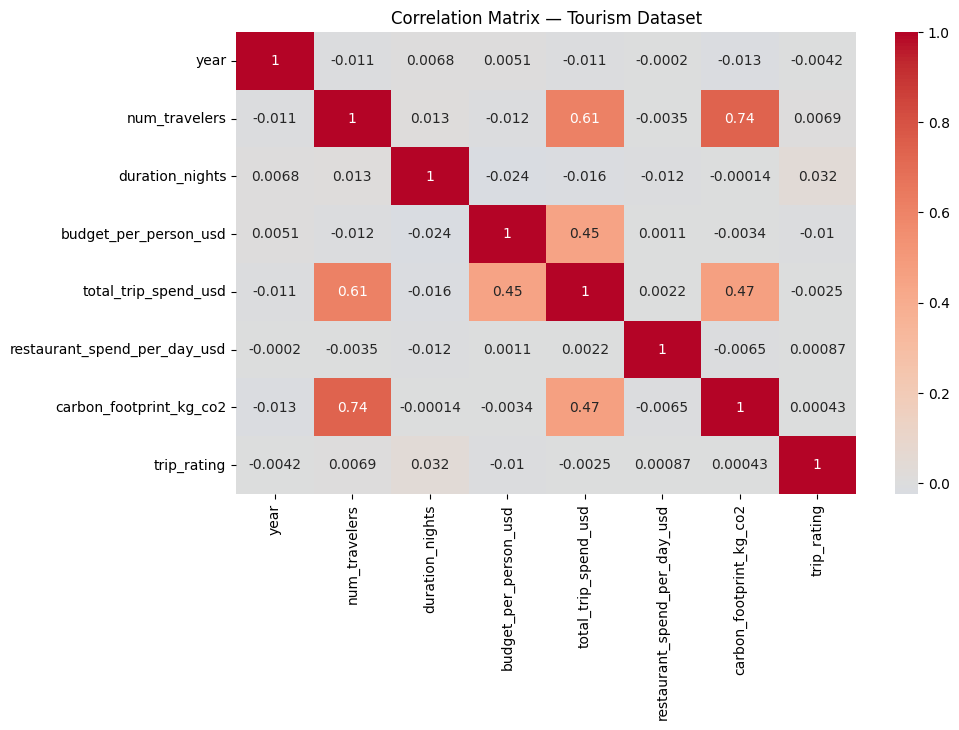

In [32]:
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Tourism Dataset")
plt.show()

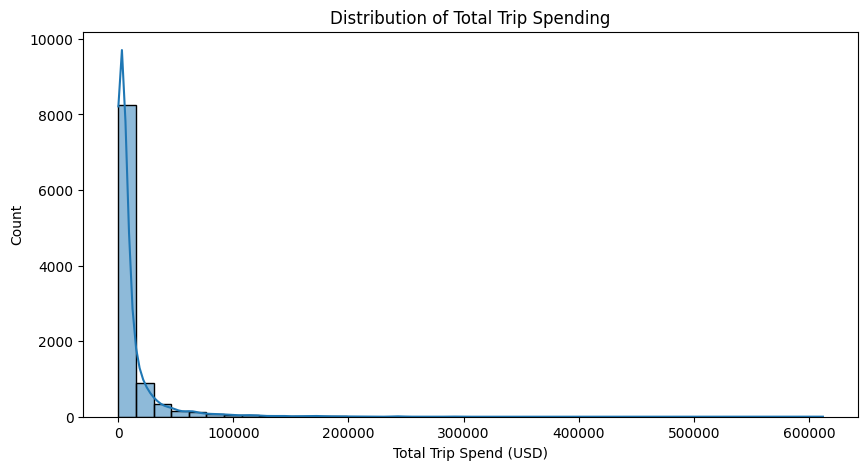

In [33]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["total_trip_spend_usd"], bins=40, kde=True)
plt.title("Distribution of Total Trip Spending")
plt.xlabel("Total Trip Spend (USD)")
plt.show()

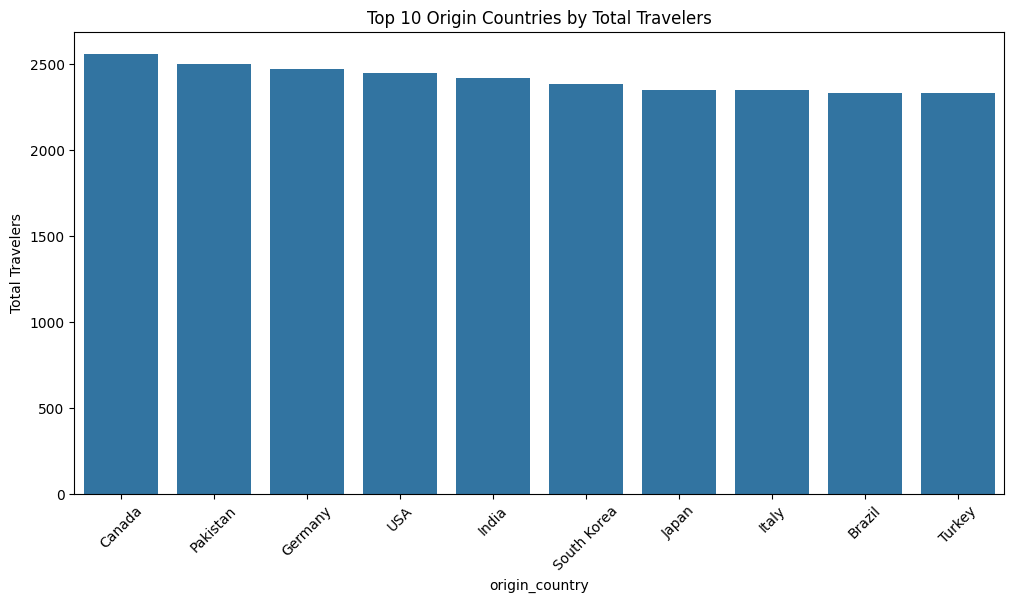

In [34]:
top_countries = (
    df_clean.groupby("origin_country")["num_travelers"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.xticks(rotation=45)
plt.title("Top 10 Origin Countries by Total Travelers")
plt.ylabel("Total Travelers")
plt.show()